In [85]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx # TODO: use this
from scipy.integrate import solve_ivp
import os
import copy
import random

from control_utils.politopic_representation import *
from control_utils.uio import *
from control_utils import levants

rng_seed = 5

np.random.seed(rng_seed)
random.seed(rng_seed)

# nx.random

In [86]:
# Constants
k = 10
b = 0.7
m = 0.25

# Number of subsystems
N = 6

# Convergance rate
eta = 1

# Simulation time
time = 10

# tolerance
eps = 1e-6


In [87]:
# Initial States
x0_systems = np.array([
     3, -2,
     2,  1,
     3,  2,
    4,  2,
    -1,  0,
     0, -5
])/10
x0_observer = np.zeros(x0_systems.shape)
# x0_observer = np.array([
#      3, -2,
#      2,  1,
#      3,  2,
#     4,  2,
#     -1,  0,
#      0, -9
# ])+1
x0_levants = np.zeros(4*N)

x0 = np.concat([x0_systems, x0_observer, x0_levants], axis=0)

In [88]:
x0.shape

(48,)

In [89]:
# System matrices
# A = np.array([
#     [ 0, 1 ],
#     [ -k/m, -b/m]
# ])

A = np.array([
    [ 0, 1 ],
    [ 0, 0]
])

C = np.array([
    [ 1, 0 ]
])

A, C

(array([[0, 1],
        [0, 0]]),
 array([[1, 0]]))

In [90]:
# Observability
np.linalg.matrix_rank(ct.obsv(A, C)) == A.shape[0]

np.True_

In [91]:
# Validite domain of the model (D) -> TODO: update values - but as it is linear it should be R2
# hyperplanes
a_i = np.array([
    [1, -1, 0, 0],
    [0, 0, 1, -1]
])
b_i = np.array([5, 5, 300, 300]).reshape(4, 1)+1

# Subset of D -> used to guarantee x_hat stays in D
bR_i = np.array([5, 5, 250, 250]).reshape(4, 1)

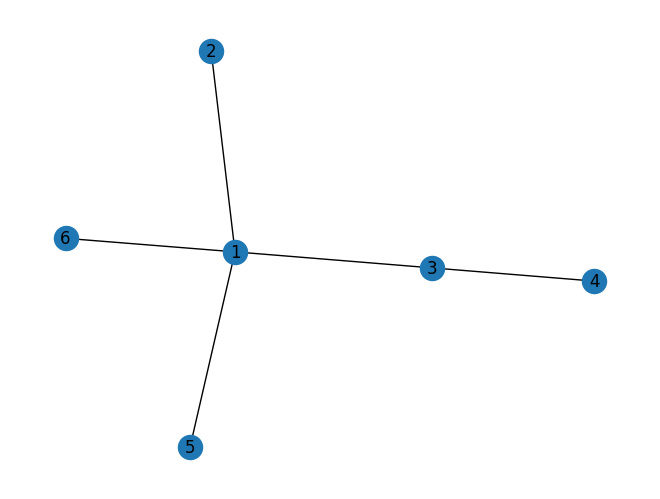

In [92]:
# Connections Graph construction
m = 1    # random min initial conections
p = 0.04 # probability to add m new edges
q = 0.02 # probability to alter m existing edges

# G = ntx.barabasi_albert_graph(10, 1, seed=10) # no cycles
# G = ntx.erdos_renyi_graph(20, .2) # random edges
G = ntx.extended_barabasi_albert_graph(N, m, p, q, seed=rng_seed) # both cycles and direct connections

mapping = {i: i + 1 for i in G.nodes()}
G = ntx.relabel_nodes(G, mapping)

ntx.draw(G, pos=ntx.spring_layout(G, pos={'0': (0, 0)}, iterations=500, seed=rng_seed), with_labels=True)

In [93]:
# dG = ntx.DiGraph(G)
# dG.remove_edges_from([(1, 2), (1, 3), (1, 5), (3, 4), (2, 6)])
# ntx.draw(dG, ntx.spring_layout(dG, seed=rng_seed, iterations=100), with_labels=True)

In [94]:
# use adj matrix of G to create interconections
# use adj matrix of dG to rebuild g_ij
# ntx.to_numpy_array(dG) # adjacency - outbound look at rows - inbound deals with col

In [95]:
# LMIs
nx = A.shape[0]
ny = C.shape[0]

P_trace = 0
P_cell = []
L_till_cell = []

for i in range(N):
    P_i = cp.Variable((nx, nx), symmetric=True)
    L_till_i = cp.Variable((nx, ny))

    P_cell.append(P_i)    
    L_till_cell.append(L_till_i)

constrains = []

for i in range(N):

    P_trace += cp.trace(P_cell[i])
    constrains += [ P_cell[i] >> eps ] # the same as P > 0

    M = P_cell[i]@A - L_till_cell[i]@C + eta*P_cell[i]
    constrains += [ M + M.T << -eps ] # linear case
        
    for j in range(a_i.T.shape[0]): # check the need for this one as the model is linear
        aj = np.expand_dims(a_i.T[j], axis=1)
        phi = phi_z(a_i.T, aj, bR_i) # still necessary?
        sj = 1/(b_i[j] - phi) * aj

        M = cp.bmat([
            [np.eye(1), sj.T],
            [sj       , P_i],
        ])
        constrains += [ M >> 0 ]

P_diag = cp.bmat([
    [P_cell[0], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), P_cell[1], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[2], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[3], np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[4], np.zeros(shape=(2, 2))],
    [np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), np.zeros(shape=(2, 2)), P_cell[5]],
])

prob = cp.Problem(cp.Minimize(cp.trace(P_diag)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Aug 29 04:01:04 PM: Your problem has 36 variables, 264 constraints, and 0 parameters.
(CVXPY) Aug 29 04:01:04 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Aug 29 04:01:04 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Aug 29 04:01:04 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Aug 29 04:01:04 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Aug 29 04:01:04 PM: Compiling problem (target solver=MOSEK).
(

In [96]:
P_diag.value

array([[ 1.13031017e-05, -3.26772951e-06,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.26772951e-06,  2.76764269e-06,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.13031017e-05,
        -3.26772951e-06,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -3.26772951e-06,
         2.76764269e-06,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.0000000

In [97]:
is_positive_defined = []
for i in range(N):
    i_is_positive_defined = True if all(np.linalg.eig(P_cell[i].value).eigenvalues > 0) else False
print(f'e.g.: P[1] = \n{P_cell[0].value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {"Positive Defined" if all(is_positive_defined) else "NOT Positive Defined"}")

e.g.: P[1] = 
[[ 1.13031017e-05 -3.26772951e-06]
 [-3.26772951e-06  2.76764269e-06]]
The solution is 'optimal', with Trace(P) = 1.00 and P is Positive Defined


In [98]:
L_cell = []

for i in range(N):
    P_i_inv = np.linalg.inv(P_cell[i].value)
    L_cell.append(P_i_inv@L_till_cell[i].value)
    print(L_cell[i])

[[51033.1143815 ]
 [60256.39882429]]
[[51033.1143815 ]
 [60256.39882429]]
[[51033.1143815 ]
 [60256.39882429]]
[[51033.1143815 ]
 [60256.39882429]]
[[51033.1143815 ]
 [60256.39882429]]
[[2.38122099e+00]
 [2.60138024e+03]]


In [99]:
A = np.array([
    [ 0, 1 ],
    [ -k/m, -b/m]
])


# Simulation
def f_x(x_i: np.ndarray) -> np.ndarray[float]:
    """System Dynamics

    Parameters
    ----------
    x_i : np.ndarray
        i-th system states
    
    Returns
    f(x_i) : np.ndarray
    """
    # print(f"x_i: {x_i}, shape: {x_i.shape}")
    # print(f"A@x_i: {A@x_i}, shape: {(A@x_i).shape}")
    return np.expand_dims(A@x_i, axis=1)

def h_x(x_i: np.ndarray) -> np.ndarray[float]:
    """System output

    Parameters
    ----------
    x_i : np.ndarray
        i-th system states
    
    Returns
    h(x_i) : np.ndarray
    """
    return np.expand_dims(C@x_i, axis=1)

def gd_x(i: int, n: int, x: np.ndarray, G: ntx.Graph) -> list[np.ndarray[float], np.ndarray[float]]: # check if this typing is correct
    """Calculates UIs

    Parameters
    ----------
    i : int
        Current system
    n : int
        Number of states
    x : np.ndarray
        All states
    G : ntx.Graph
        Graph of interconnections
    
    Returns
    ----------
    G*d(x), d(x) : np.ndarray[float], np.ndarray
    """

    # TODO: handle this differently
    # removing levants differentiations and observer
    # n = (x.shape[0] - 4) // (2*G.number_of_nodes())
    gd = np.zeros(n)
    gd_decoupled = []
    
    i_id = i * N
    x_i = x[i_id:i_id+n]
    
    for edge in G.edges(i):
        j = edge[1] - 1 # mapping from 1~N to 0~N-1
        j_id = j * n
        x_j = x[j_id:j_id+n]

        # affects only the second state
        d = -math.tanh(x_j[1] - x_i[1])
        gd[1] += d

        gd_decoupled.append(d)

    gd = gd.reshape((n, 1))
    gd_decoupled = np.array(gd_decoupled).reshape(len(gd_decoupled), 1)

    return gd, gd_decoupled

def G_i() -> np.ndarray:
    return np.array([
        [0],
        [-1] # TODO: fix with degree
    ]).reshape((2, 1))

def Gamma_inv() -> np.ndarray:
    """Calculates Gamma_inv(x)

    Returns
    ----------
    Gamma_inv : np.ndarray
    """
    Gamma = G_i()[1]

    return np.array(1/Gamma)

def Q_x() -> np.ndarray:
    """Calculates Q(x)
    
    Returns
    ----------
    Q(x) : np.ndarray
    """
    g_i = G_i()
    gamma_inv = Gamma_inv()
    Q  = g_i@gamma_inv # TODO: check why i need to force this -1

    return np.expand_dims(Q, axis=1)

def Psi_x(x_i: np.ndarray):
    Psi = f_x(x_i)[1]
    Psi = np.array(Psi).reshape((len(Psi), 1))

    return Psi

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    """Returns dot_Y_levants
    """

    # z1 = y1 = x2
    # z2 = dot_y1 = dot_x2
    # Only necessary up to z2 but higher order helps improve quality 
    lambda_y1 = .1*np.array([25, 20, 15, 10])

    n_y1 = lambda_y1.shape[0]
    id_y1 = 0

    z_y1 = Y_levants[id_y1:n_y1]
    y1 = y[0]

    dot_y1 = levants.differentiator(y1, z_y1, lambda_y1)

    return np.concat([dot_y1], axis=0)

def model(t: float, x: np.ndarray[float], nx: int, G: ntx.Graph, dist_hist: list[list]):
    """Simulates system model
    
    Parameters:
    ----------
    t : float
        Current simulation time in seconds
    x : np.ndarray[float]
        Current system states / observer states / levants integrated
    G : ntx.Graph
        Graph of interconections
    dist_hist : list[list]
        empty list to store UI history
    
    Returns
    ----------
    dot_x : np.ndarray
    """

    print(f"t={t}s")

    # system states / observer states / levants integrated
    xdot = np.zeros(shape=x.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # TODO: handle this differently
    # removing levants differentiations and observer
    N = G.number_of_nodes()
    # nx = (x.shape[0] - 4) // (2*G.number_of_nodes())

    x_i_cell = []
    x_hat_i_cell = []
    Y_levants_i_cell = []

    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_levants = id_hat + N*nx

        x_i_cell.append(x[id:id+nx])
        x_hat_i_cell.append(x[id_hat:id_hat+nx])
        Y_levants_i_cell.append(x[id_levants:id_levants+4])

    dist_hist[0].append(t)
    for i in range(N):
        id = i * nx
        id_hat = id + N*nx
        id_Y_levants = id_hat + N*nx

        x_i = x_i_cell[i]
        x_hat_i = x_hat_i_cell[i]
        Y_levants_i = Y_levants_i_cell[i]

        # print(f"here: {i}")
        i_mapped = i + 1
        d_i, d_i_decoupled = gd_x(i_mapped, nx, x, G)

        # print(f"f_x: {f_x(x_i).shape}, d_i: {d_i.shape}")
        xdot[id:id+nx] = f_x(x_i) + d_i
        y_i = h_x(x_i)
        y_i_hat = h_x(x_hat_i)

        Q = Q_x()
        # print(f"Q: {Q}")
        Psi_hat = Psi_x(x_hat_i) # using this breaks
        # Psi_hat = Psi_x(x_i) # exact value
        Y = np.array([
            # Y_levants_i[2] # levants differentiattor
            xdot[id+1, 0] # exact value
        ])

        L = L_cell[i]

        d_hat_decoupled = Gamma_inv()@(Y - Psi_hat)
        # print(f"f_x: {(f_x(x_hat_i).shape)}, Q@delta: {(Q@(Y - Psi_hat)).shape}")
        # print(f"d_hat_decoupled: {d_hat_decoupled}, d_i: {d_i}, d_i_decoupled: {d_i_decoupled}")
        # print(f"Y: {Y}, Psi: {Psi_hat}")
        delta = np.expand_dims(y_i - y_i_hat, axis=1)
        xdot[id_hat:id_hat+nx] = f_x(x_hat_i) + Q@(Y - Psi_hat) + L@delta # delta

        # dot_Y = dot_Y_levants(y_i, Y_levants_i)
        # xdot[id_Y_levants:id_Y_levants+4] = dot_Y

        if len(dist_hist) < i + 2:
            dist_hist.append([[], []])
        
        dist_hist[i+1][0].append(d_i_decoupled)
        dist_hist[i+1][1].append(d_hat_decoupled)

    return xdot.flatten()

In [100]:
sim_time = (0, time)
dist_hist = [[]]

result = solve_ivp(model, sim_time, x0, args=(A.shape[0], G, dist_hist), method="LSODA", dense_output=True)  # LSODA
t = result.t
x = result.y

t=0.0s
t=1.3122452104175236e-09s
t=1.3122452104175236e-09s
t=2.6244904208350472e-09s
t=2.6244904208350472e-09s
t=4.1823946696887444e-07s
t=4.1823946696887444e-07s
t=8.338544435169138e-07s
t=8.338544435169138e-07s
t=1.2494694200649531e-06s
t=1.2494694200649531e-06s
t=3.7911471866161003e-06s
t=3.7911471866161003e-06s
t=6.3328249531672474e-06s
t=6.3328249531672474e-06s
t=8.874502719718395e-06s
t=8.874502719718395e-06s
t=1.1416180486269543e-05s
t=1.1416180486269543e-05s
t=1.7546251550184516e-05s
t=1.7546251550184516e-05s
t=2.367632261409949e-05s
t=2.367632261409949e-05s
t=2.9806393678014462e-05s
t=2.9806393678014462e-05s
t=3.593646474192944e-05s
t=3.593646474192944e-05s
t=4.2066535805844415e-05s
t=4.2066535805844415e-05s
t=5.088454382570113e-05s
t=5.088454382570113e-05s
t=5.970255184555784e-05s
t=5.970255184555784e-05s
t=6.852055986541456e-05s
t=6.852055986541456e-05s
t=7.733856788527126e-05s
t=7.733856788527126e-05s
t=8.615657590512797e-05s
t=8.615657590512797e-05s
t=9.693414126394517e-05

In [101]:
dist_hist_filtered = []

for i in range(0, len(dist_hist)):
    for j in range(len(dist_hist[i])):
        dist_hist[i][j] = np.array(dist_hist[i][j])

for i in range(N+1):
    dist_hist_filtered.append([])

for i in range(len(dist_hist[0])-1):
    if dist_hist[0][i] < dist_hist[0][i + 1]:
        dist_hist_filtered[0].append(dist_hist[0][i])
        for j in range(N):
            dist_hist_filtered[j+1].append(dist_hist[j+1][0][i])

In [102]:
def plot_graph(x, nx):
    plt.figure(dpi=150, constrained_layout=True)
    # plt.suptitle(f'{N}-Interconnected Oscilators', y=1.0)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)
        plt.scatter(x0[ind], x0[ind+1], s=30, facecolors='none', edgecolors='k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind, :], x[ind+1, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind_hat, :], x[ind_hat+1, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        plt.grid(which='both')
    
    legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

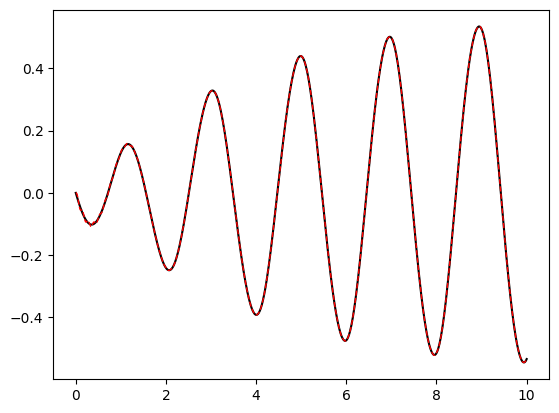

In [103]:
i = 5

ind = i * nx
ind_hat = ind + N*nx

plt.plot(t, x[ind, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
plt.plot(t, x[ind_hat, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')

# plt.plot(t, x[ind+1, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
# plt.plot(t, x[ind_hat+1, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')

# plt.ylim([-0.05, 0.05])
# plt.xlim([2.5, 2.75])

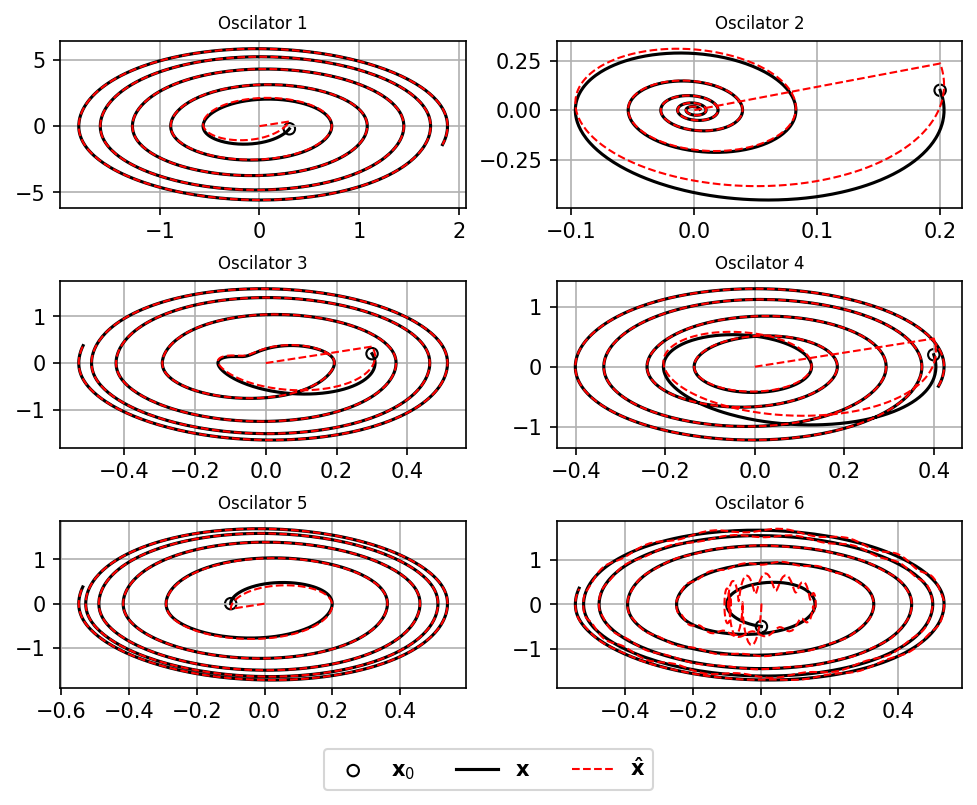

In [104]:
plot_graph(x, 2)

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_90152\3300456211.py:16: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(dist_hist[0], -dist_hist[i][1][:, 0], label=f'$\hat{{d}}_{i}$')


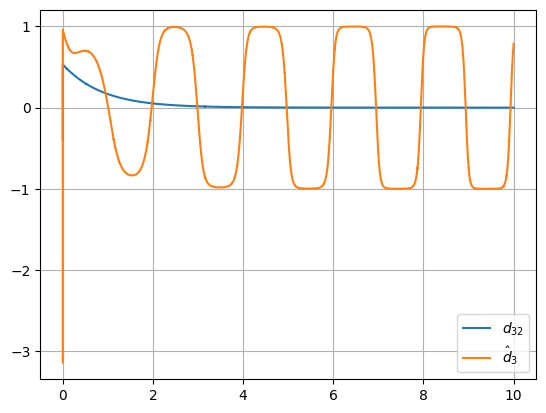

In [112]:
# for i in range(1, N+1):
# for i in range(1, 1+1):

# i = 1
# plt.plot(dist_hist[0], dist_hist[i][0][:, 0] + dist_hist[i][0][:, 1] + dist_hist[i][0][:, 2] + dist_hist[i][0][:, 3], label=f"$d_{i}$")
# plt.plot(dist_hist[0], dist_hist[i][1][:, 0], label=f'$\hat{{d}}_{i}$')

# i = 2
# plt.plot(dist_hist[0], dist_hist[i][0][:, 0], label=f"$d_{i}$")
# plt.plot(dist_hist[0], dist_hist[i][1][:, 0], label=f'$\hat{{d}}_{i}$')

i = 3
# plt.plot(dist_hist[0], dist_hist[i][0][:, 0], label=f"$d_{{{i}1}}$")
# plt.plot(dist_hist[0], dist_hist[i][0][:, 1], label=f"$d_{{{i}2}}$")
plt.plot(dist_hist[0], dist_hist[i][0][:, 1]+dist_hist[i][0][:, 1], label=f"$d_{{{i}2}}$")
plt.plot(dist_hist[0], -dist_hist[i][1][:, 0], label=f'$\hat{{d}}_{i}$')

# i = 5
# plt.plot(dist_hist[0], dist_hist[i][0][:, 0], label=f"$d_{i}$")
# plt.plot(dist_hist[0], -dist_hist[i][1][:, 0], label=f'$\hat{{d}}_{i}$')

# plt.ylim([-2, 1.1])
# plt.xlim([3.5, 4])
plt.legend()
plt.grid()
plt.savefig(f".figures/dist_{N}", dpi=600)
plt.show()